# HTTP2vec - Reproduction and Critical Study

Reproduction of **"HTTP2vec: Embedding of HTTP Requests for Detection of Anomalous
Traffic"** (Gniewkowski et al., 2021, arXiv:2108.01763) on the **CSIC 2010** dataset.

**Problem.** Most web attacks (SQL injection, XSS, CRLF, ...) travel over HTTP.
We want to flag anomalous HTTP requests. **Idea of the paper.** Treat an HTTP
request as text, learn a language model (RoBERTa) on *normal* traffic only, use
its hidden states to embed each request, then classify the embeddings.

This notebook walks through: data loading and inspection, EDA, the embedding
"feature engineering", model training (supervised classifiers **and** an
unsupervised Isolation Forest), evaluation, and error analysis. All logic lives
in the `http2vec` package; cells just orchestrate it.

## Colab bootstrap

When this notebook is opened directly from GitHub in Google Colab, only the
notebook file is present - the `http2vec` package and the CSIC2010 dataset are
not. This cell clones the repo, installs the package, and downloads the data. It
is a no-op when run locally (where the repo is already present), so the same
notebook works in both places.

In [1]:
import sys, os, pathlib

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.chdir("/content")
    !rm -rf /content/cyberAno /cyberAno
    !git clone https://github.com/nirmanor1/cyberAno.git /content/cyberAno
    os.chdir("/content/cyberAno")
    !pip install -q -e . sentencepiece
    if not pathlib.Path("/content/cyberAno/data/raw/normalTrafficTraining.txt").exists():
        !python scripts/download_data.py --dest data/raw
    print("cwd is now:", os.getcwd())
else:
    print("Local run: skipping Colab bootstrap.")

Cloning into '/content/cyberAno'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 149 (delta 31), reused 140 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 15.92 MiB | 11.69 MiB/s, done.
Resolving deltas: 100% (31/31), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for http2vec (pyproject.toml) ... done
cwd is now: /content/cyberAno


## 0. Setup

In [ ]:
import os, sys, pathlib
root = pathlib.Path.cwd()
for _ in range(6):
    if (root / "pyproject.toml").exists() or (root / "data" / "raw").is_dir():
        break
    root = root.parent
os.chdir(root)
try:
    import http2vec  # noqa: F401
except ModuleNotFoundError:
    if (root / "src" / "http2vec").is_dir():
        sys.path.insert(0, str(root / "src"))
    import http2vec  # noqa: F401

%matplotlib inline
import numpy as np
import pandas as pd

from http2vec.config import ExperimentConfig
from http2vec.utils import configure_logging, set_seed, resolve_device
from http2vec.visualization.plots import save_figure

configure_logging()
print("http2vec", http2vec.__version__, "| device:", resolve_device("auto"))

# Every figure is saved here (in addition to being shown inline) so the plots can
# be reused directly in the written report. Use show(fig, name) throughout.
REPORTS_DIR = pathlib.Path("reports")
FIG_DIR = REPORTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def show(fig, name):
    # Save the figure into reports/figures and return it for inline display.
    save_figure(fig, name, FIG_DIR)
    return fig

http2vec 0.1.0 | device: cuda


### Choose a configuration profile

The default here is the **`small`** profile: the full paper-size RoBERTa on a
seeded **40% subset** for **5 epochs** - a lighter stand-in for the full run.
Both profiles are heavy enough that a GPU (CUDA) is recommended.

- `small` - full paper-size model on a seeded 40% subset, 5 epochs (default here).
- `paper` - full dataset, paper-size RoBERTa, 10 epochs.

In [ ]:
PROFILE = "small"       # "small" (40% / 5ep, full model) | "paper" (full / 10ep)

RAW_DIR = pathlib.Path("data/raw")
REQUIRED = ["normalTrafficTraining.txt", "normalTrafficTest.txt", "anomalousTrafficTest.txt"]
missing = [name for name in REQUIRED if not (RAW_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "Missing CSIC2010 files in data/raw: " + ", ".join(missing)
        + ". Download them first: python scripts/download_data.py (see data/README.md)."
    )

kwargs = dict(raw_dir=str(RAW_DIR), device="auto")
if EPOCHS_OVERRIDE is not None:
    kwargs["num_train_epochs"] = EPOCHS_OVERRIDE
config = getattr(ExperimentConfig, PROFILE)(**kwargs)
set_seed(config.seed)
config

ExperimentConfig(data=DataConfig(raw_dir=PosixPath('data/raw'), normal_train_file='normalTrafficTraining.txt', normal_test_file='normalTrafficTest.txt', anomalous_test_file='anomalousTrafficTest.txt', max_lm_train_samples=None, max_inference_per_class=None, subset_fraction=0.4, subset_seed=42, first_line_only=False, encode_crlf_literally=True), tokenizer=TokenizerConfig(vocab_size=30000, min_frequency=2, max_length=512), model=ModelConfig(hidden_size=768, num_hidden_layers=6, num_attention_heads=12, intermediate_size=3072, num_train_epochs=5, per_device_batch_size=32, learning_rate=5e-05, weight_decay=0.01, warmup_ratio=0.06, mlm_probability=0.15, eval_fraction=0.05), embedding=EmbeddingConfig(last_n_layers=4, token_pooling='mean', line_aggregation='mean', batch_size=32), classifier=ClassifierConfig(cv_folds=5, test_size=0.3, random_state=42, scale_features=True, lr_max_iter=2000, rf_n_estimators=100, svc_c=1.0, svc_max_iter=5000, gb_n_estimators=100, knn_n_neighbors=15, iforest_n_esti

## 1. Data loading and inspection

The loader returns three views (matching the paper): `lm_train` (normal-only, used
to train the language model), `inference` (labelled normal + anomalous, used for
classification) and `tokenizer_corpus` (all traffic, used to train the tokenizer).

In [4]:
from http2vec.data.loaders import Csic2010Loader

bundle = Csic2010Loader(config.data).load()
print(f"lm_train (normal only):      {len(bundle.lm_train)}")
print(f"inference (normal+anomaly):  {len(bundle.inference)}")
print(f"tokenizer_corpus (all):      {len(bundle.tokenizer_corpus)}")

# Peek at one normal and one anomalous request (first line only, as text).
inf = bundle.inference.requests
example_normal = next(r for r in inf if int(r.label) == 0)
example_anomaly = next(r for r in inf if int(r.label) == 1)
print("\nNormal  :", example_normal.request_line[:160])
print("Anomaly :", example_anomaly.request_line[:160])

[INFO] http2vec: Loaded CSIC2010: lm_train=14400, inference=24426 (normal=14400, anomaly=10026), tokenizer_corpus=38826


lm_train (normal only):      14400
inference (normal+anomaly):  24426
tokenizer_corpus (all):      38826

Normal  : GET http://localhost:8080/tienda1/publico/anadir.jsp?id=1&nombre=Jam%F3n+Ib%E9rico&precio=39&cantidad=41&B1=A%F1adir+al+carrito HTTP/1.1
Anomaly : POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1


We turn each request into a small table of **descriptive features** (length,
number of parameters, %-encoding ratio, entropy, attack-signature flags, ...).
These are *not* the model features - they exist so we can do classical EDA.

In [5]:
from http2vec.data.features import feature_frame

inference_df = feature_frame(bundle.inference)
print("shape:", inference_df.shape)
print("\ndtypes:\n", inference_df.dtypes)
inference_df.head()

shape: (24426, 16)

dtypes:
 method                   object
target_length             int64
body_length               int64
n_headers                 int64
n_query_params            int64
path_depth                int64
has_body                  int64
pct_encoding_count        int64
pct_encoding_ratio      float64
digit_ratio             float64
upper_ratio             float64
non_alnum_ratio         float64
shannon_entropy         float64
contains_sql_keyword      int64
contains_script_tag       int64
label                     int64
dtype: object


,method,target_length,body_length,n_headers,n_query_params,path_depth,has_body,pct_encoding_count,pct_encoding_ratio,digit_ratio,upper_ratio,non_alnum_ratio,shannon_entropy,contains_sql_keyword,contains_script_tag,label
0,GET,123,0,10,5,3,0,3,0.02439,0.113821,0.056911,0.195122,4.869027,0,0,0
1,POST,48,74,12,0,3,1,3,0.02459,0.114754,0.057377,0.188525,4.840254,0,0,0
2,GET,113,0,10,5,3,0,0,0.00000,0.053097,0.017699,0.159292,4.628747,0,0,0
3,GET,62,0,10,1,3,0,0,0.00000,0.096774,0.000000,0.161290,4.370116,0,0,0
4,POST,57,4,12,0,3,1,0,0.00000,0.098361,0.000000,0.147541,4.320688,0,0,0


In [6]:
# Data-quality checks: missing values, duplicate rows, constant (single-value)
# columns, and duplicate (exactly redundant) feature columns.
print("Missing values per column:\n", inference_df.isna().sum())
print("\nFully duplicated rows:", int(inference_df.duplicated().sum()))
constant_cols = [c for c in inference_df.columns if inference_df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)
# Transpose so each former column becomes a row; duplicated() then flags columns
# whose values are identical to an earlier one (a vectorised redundancy check).
duplicate_feature_cols = inference_df.columns[inference_df.T.duplicated()].tolist()
print("Duplicate feature columns:", duplicate_feature_cols)
inference_df.describe(include="all").T

Missing values per column:
 method                  0
target_length           0
body_length             0
n_headers               0
n_query_params          0
path_depth              0
has_body                0
pct_encoding_count      0
pct_encoding_ratio      0
digit_ratio             0
upper_ratio             0
non_alnum_ratio         0
shannon_entropy         0
contains_sql_keyword    0
contains_script_tag     0
label                   0
dtype: int64

Fully duplicated rows: 15678
Constant columns: []
Duplicate feature columns: []


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
method,24426,3,GET,17159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_length,24426.0,NaN,NaN,NaN,81.4817,75.737216,22.0,48.0,50.0,68.0,886.0
body_length,24426.0,NaN,NaN,NaN,32.436625,76.086395,0.0,0.0,0.0,18.0,835.0
n_headers,24426.0,NaN,NaN,NaN,10.595022,0.914345,10.0,10.0,10.0,12.0,12.0
n_query_params,24426.0,NaN,NaN,NaN,1.613322,3.603426,0.0,0.0,0.0,1.0,13.0
path_depth,24426.0,NaN,NaN,NaN,3.006264,0.476856,0.0,3.0,3.0,3.0,6.0
has_body,24426.0,NaN,NaN,NaN,0.297511,0.457173,0.0,0.0,0.0,1.0,1.0
pct_encoding_count,24426.0,NaN,NaN,NaN,1.865553,6.349044,0.0,0.0,0.0,2.0,114.0
pct_encoding_ratio,24426.0,NaN,NaN,NaN,0.008625,0.018992,0.0,0.0,0.0,0.010453,0.177236
digit_ratio,24426.0,NaN,NaN,NaN,0.121383,0.059961,0.048193,0.09322,0.104348,0.136364,0.64878


**Columns and index - does this make sense?** The columns are descriptive,
model-agnostic attributes (lengths, counts, ratios, entropy, attack-signature
flags) plus the `label`; the names are self-explanatory and appropriate for EDA.
The frame uses a default positional integer index (one row per request): CSIC has
no natural key (no request id, no timestamp), so a positional index is the
sensible choice and conveniently aligns row *i* with
`bundle.inference.requests[i]` for error analysis later. The checks above confirm
no missing values and no exactly-duplicated feature columns; correlation-based
redundancy is examined in the EDA section.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class balance (prevalence)

In the CSIC inference set the classes are roughly 59% normal / 41% anomalous
(the `small` subset profile keeps a seeded fraction of each file, so this ratio is
preserved). Accuracy is therefore sensitive to the imbalance - prefer F1, MCC and
ROC-AUC.

In [7]:
counts = inference_df["label"].value_counts().rename({0: "normal", 1: "anomaly"})
shares = inference_df["label"].value_counts(normalize=True).rename({0: "normal", 1: "anomaly"})
pd.DataFrame({"count": counts, "share": shares.round(3)})

,count,share
label,,
normal,14400,0.59
anomaly,10026,0.41


### 2.2 Feature distributions by class

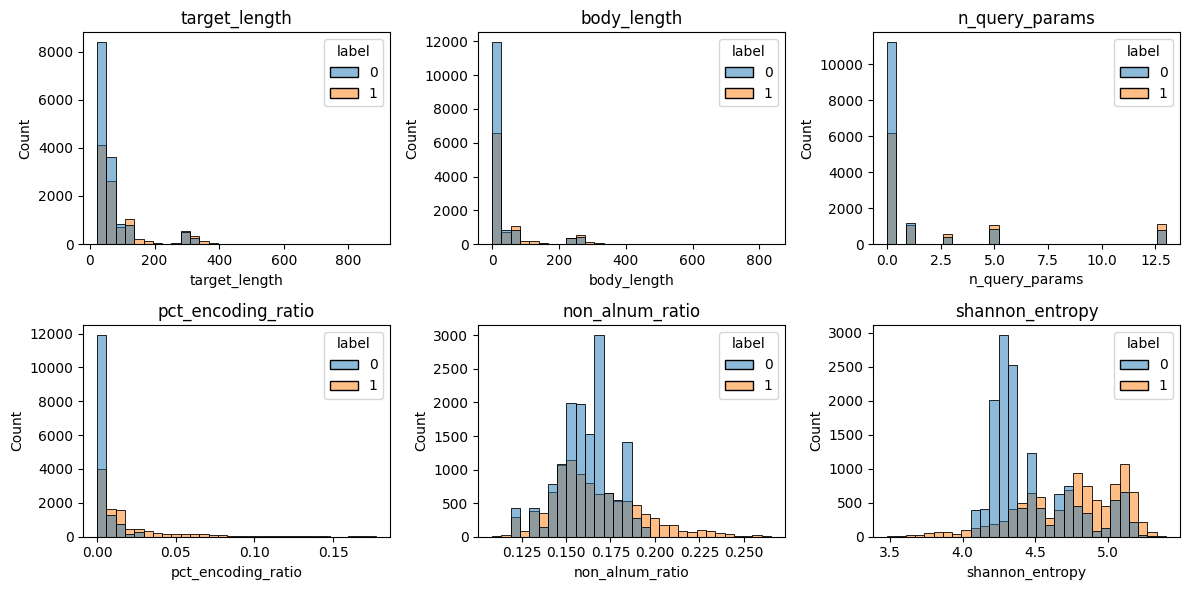

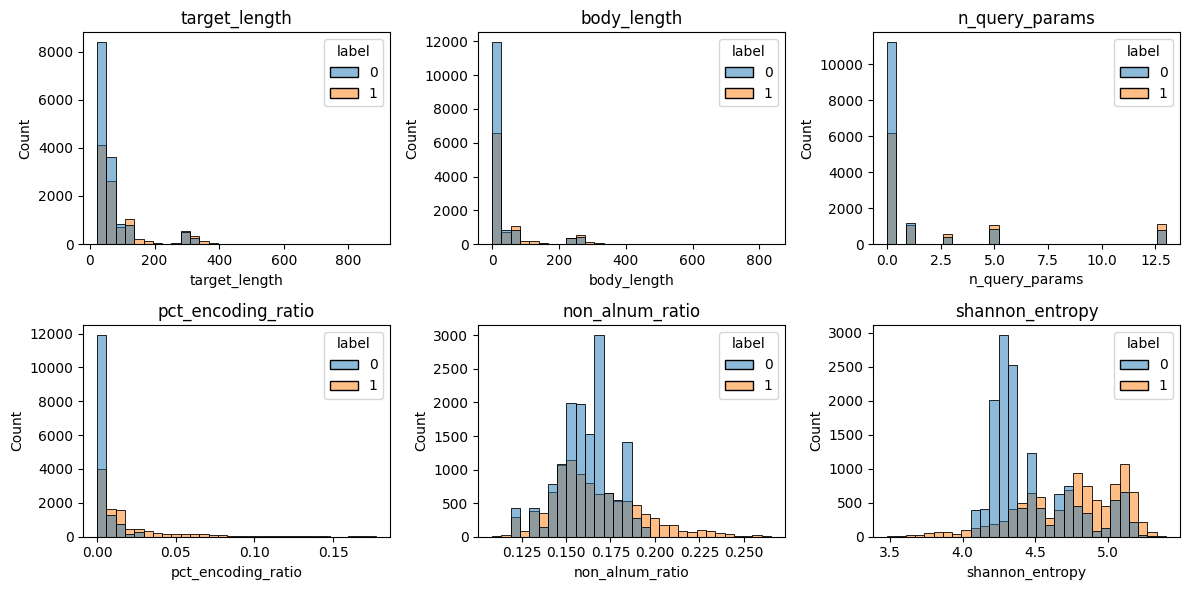

In [8]:
from http2vec.visualization.plots import plot_feature_distributions

dist_cols = ["target_length", "body_length", "n_query_params",
             "pct_encoding_ratio", "non_alnum_ratio", "shannon_entropy"]
fig = plot_feature_distributions(inference_df, dist_cols, hue="label")
show(fig, "2_2_feature_distributions")

### 2.3 Correlation analysis

We report **Spearman** correlation as the primary measure: the descriptive
features are skewed, non-normal and contain outliers (attack payloads can be very
long), and we mostly care about *monotonic* association rather than strictly
linear association. For reference:

- **Pearson** - linear association between continuous variables; sensitive to
  outliers and assumes roughly linear, normal-ish data.
- **Spearman** - rank-based; captures monotonic relationships and is robust to
  outliers and non-normality (our case).
- **Kendall** - also rank-based; preferred for small samples / many ties, with a
  more conservative interpretation.

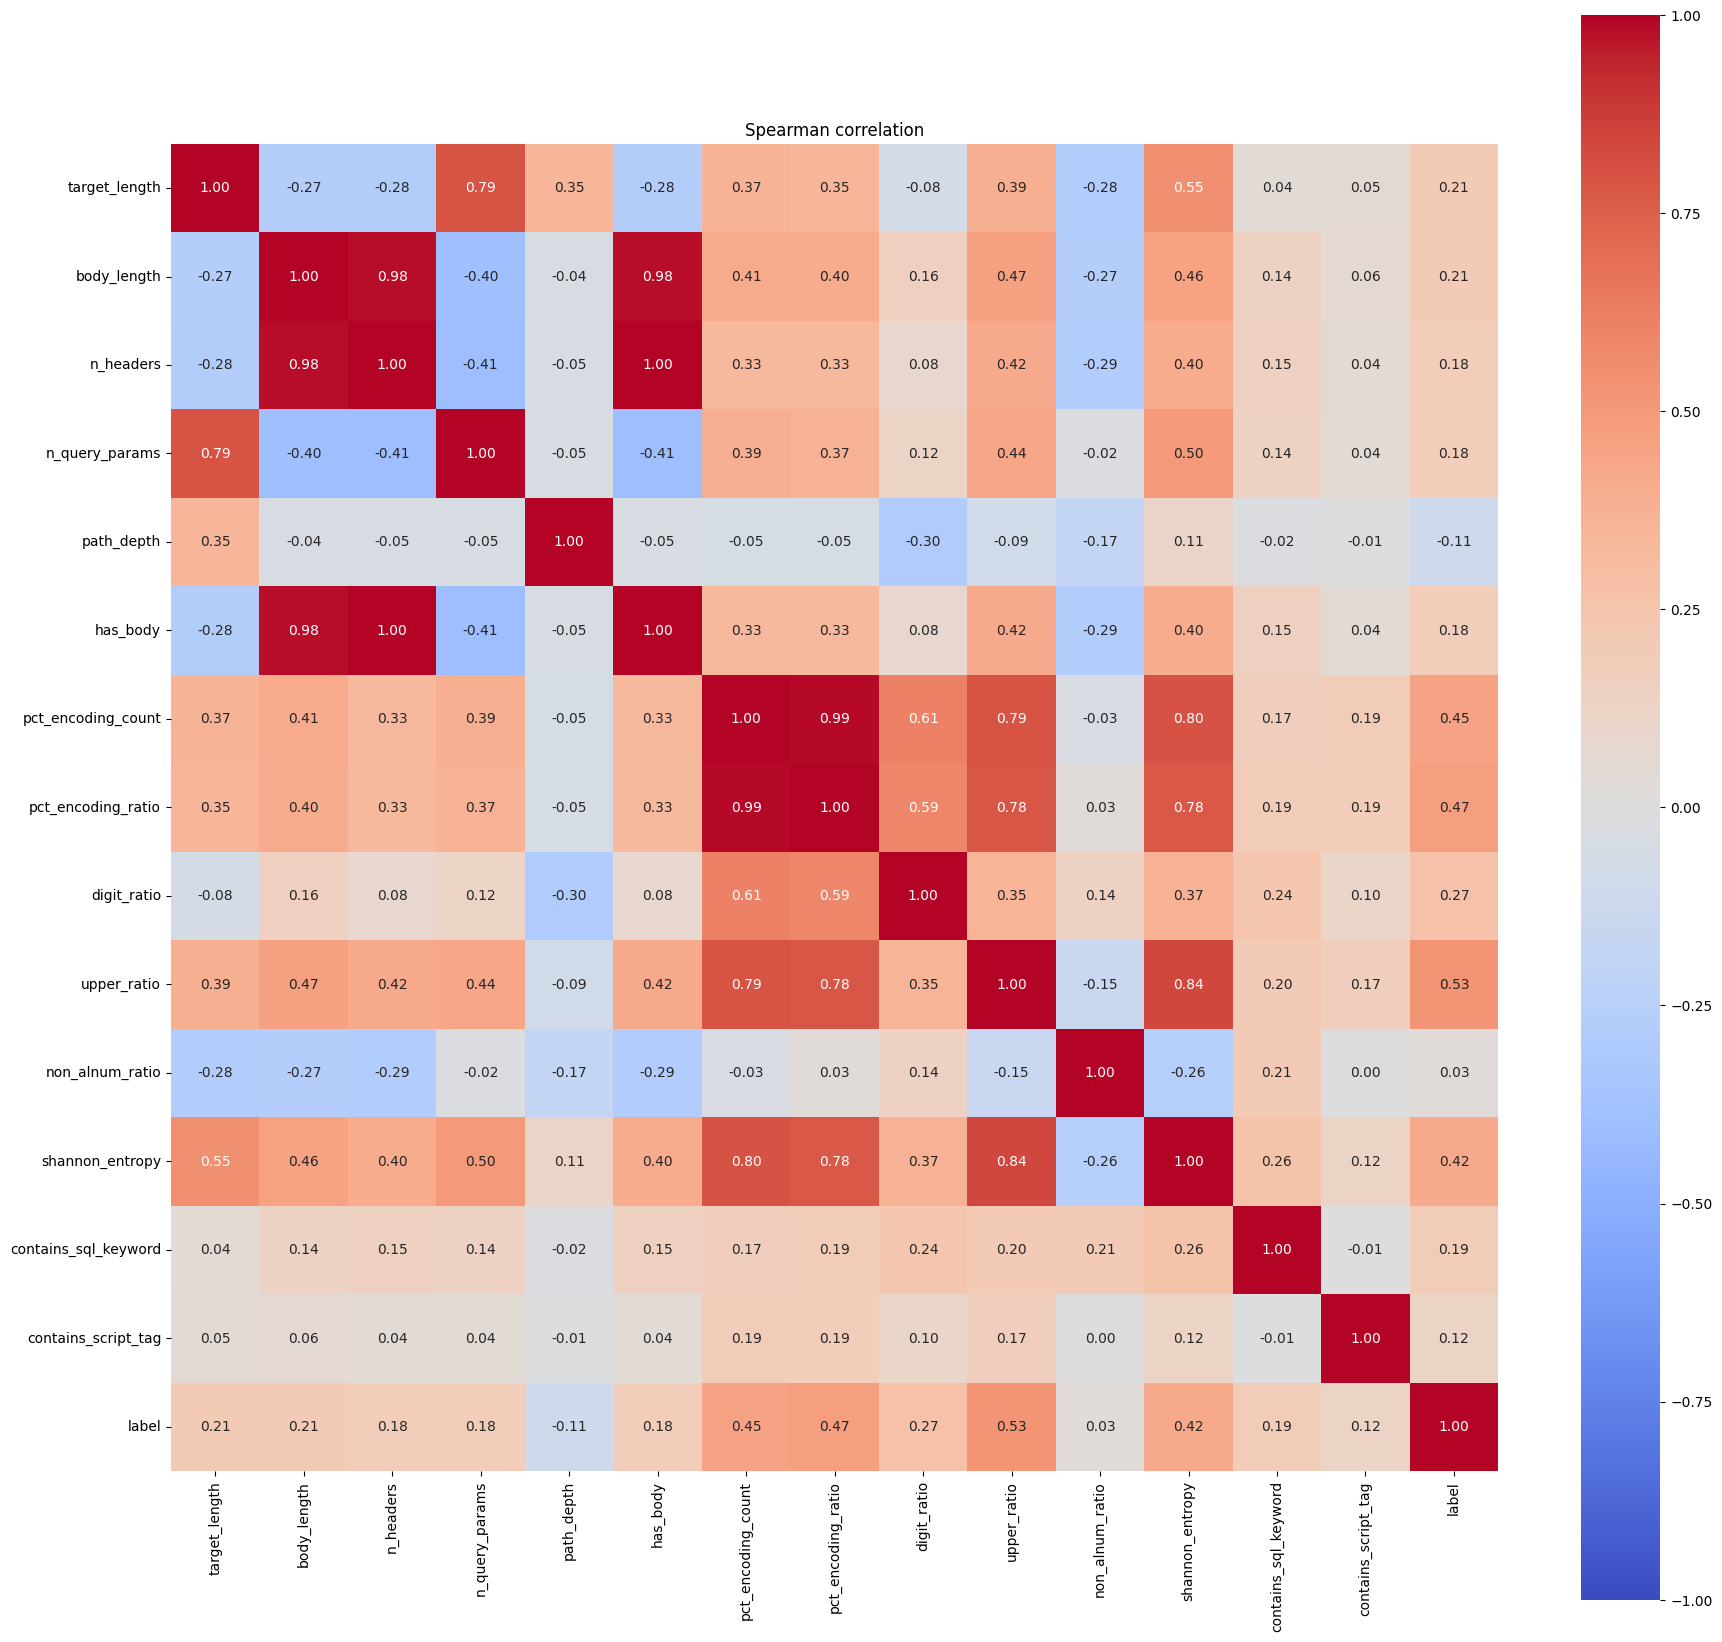

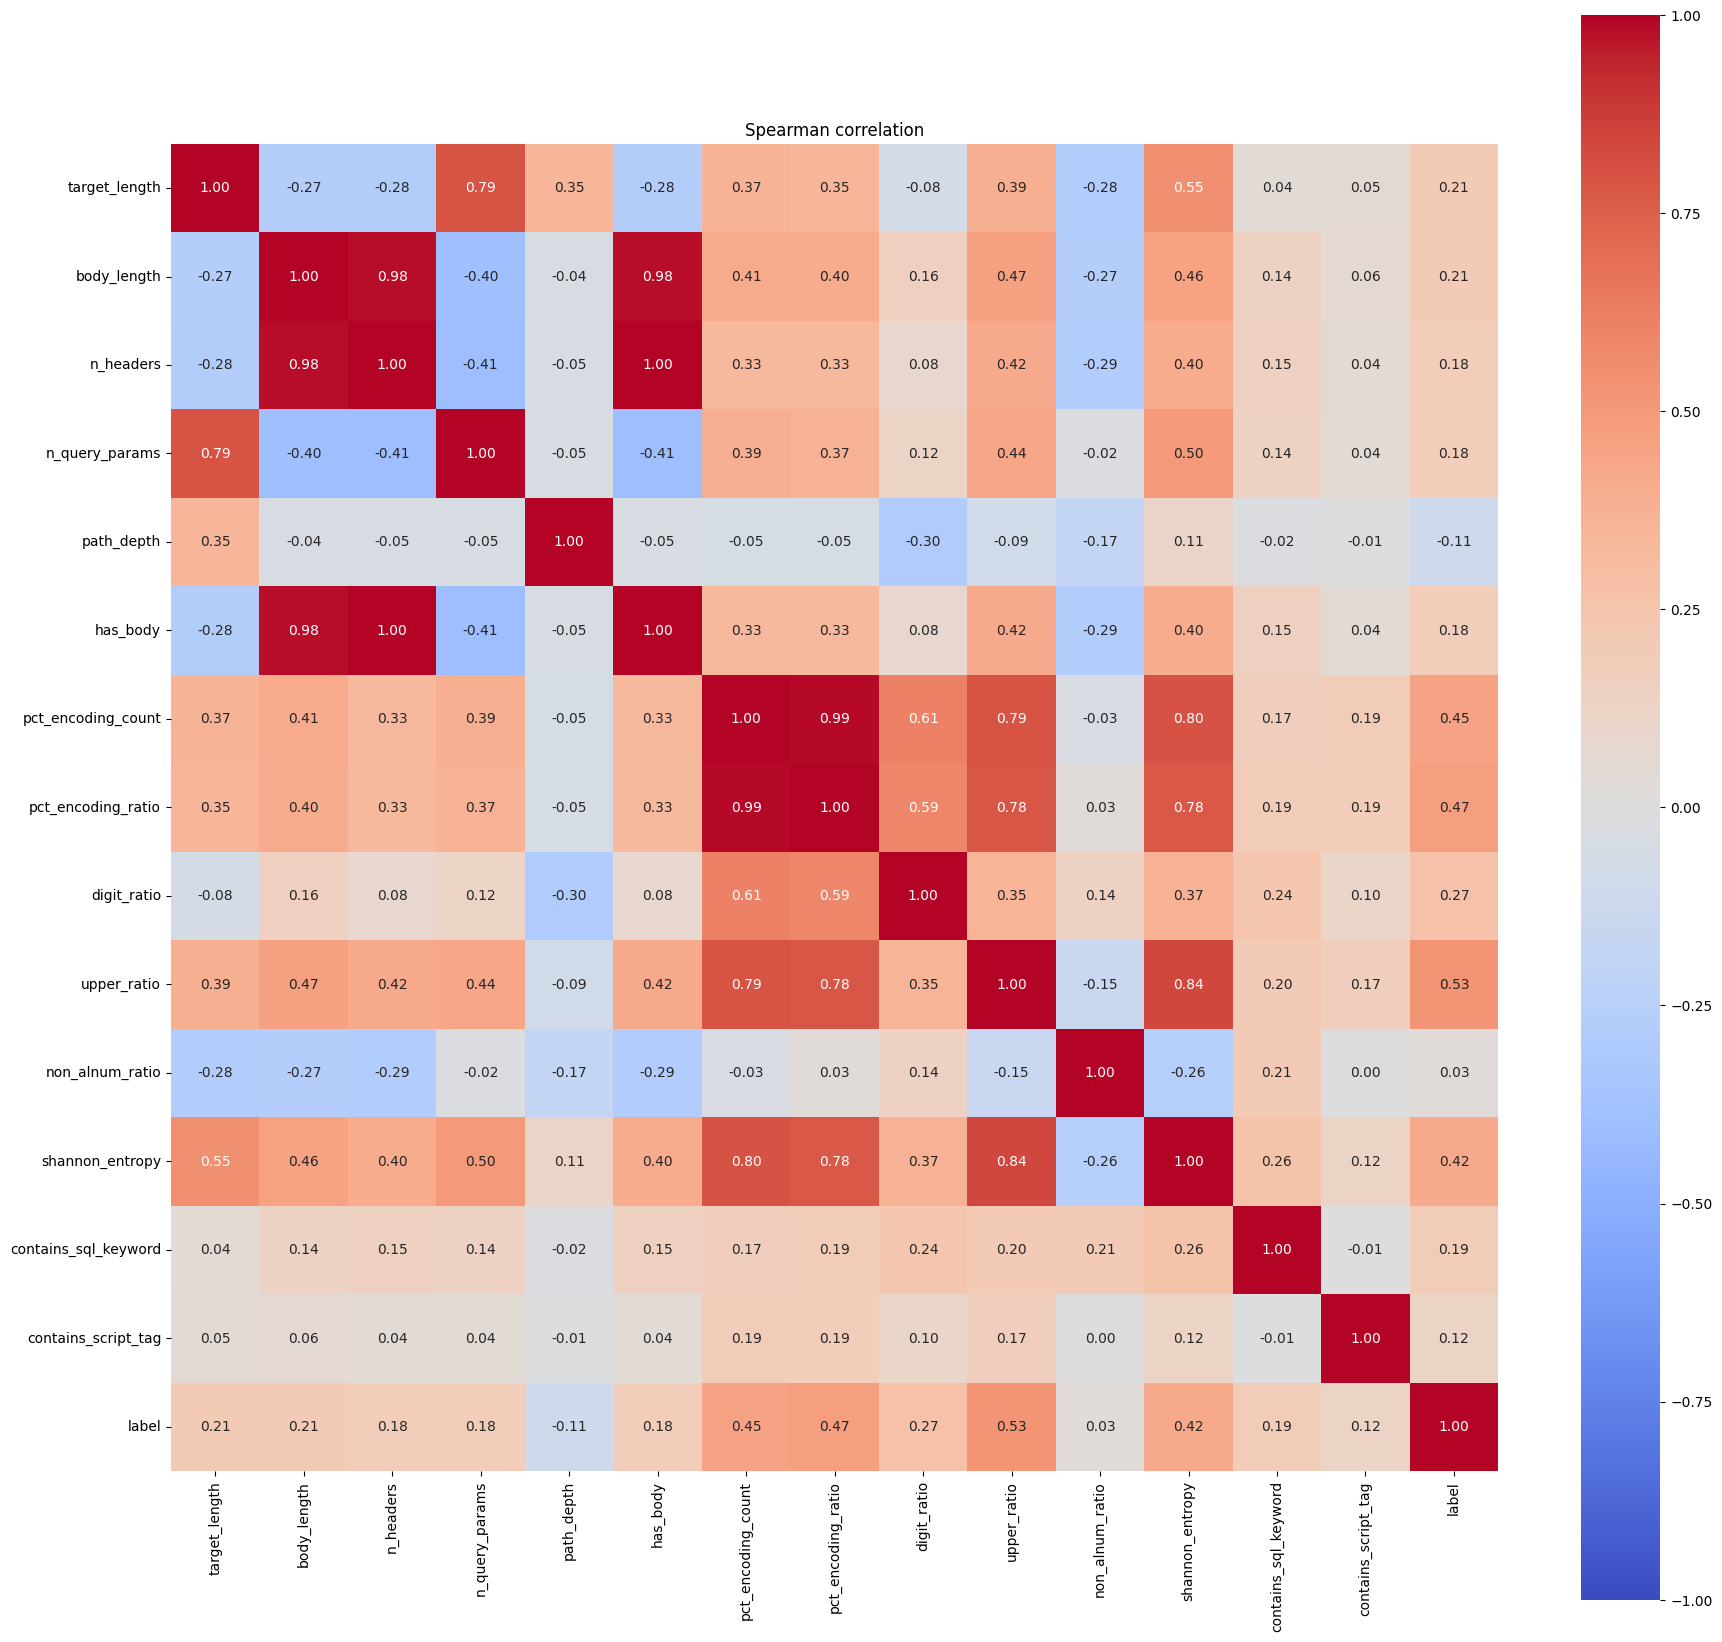

In [9]:
from http2vec.visualization.plots import plot_correlation_heatmap

fig = plot_correlation_heatmap(inference_df, method="spearman")
show(fig, "2_3_correlation_spearman")

In [10]:
# Cross-tabulate HTTP method against the label (group-by style view).
pd.crosstab(inference_df["method"], inference_df["label"].map({0: "normal", 1: "anomaly"}))

label,anomaly,normal
method,,
GET,6040,11119
POST,3818,3281
PUT,168,0


### 2.4 Outliers and temporal note

`target_length` / `body_length` are heavy-tailed - long values are often attack
payloads, so "outliers" here are signal, not noise, and we keep them. The CSIC
dataset has **no timestamps**, so a temporal analysis is not applicable; this is a
limitation to note (concept drift cannot be studied with this data alone).

In [11]:
inference_df[["target_length", "body_length", "shannon_entropy"]].describe(
    percentiles=[0.5, 0.9, 0.99]
).T

,count,mean,std,min,50%,90%,99%,max
target_length,24426.0,81.481700,75.737216,22.000000,50.000000,131.000000,340.00000,886.00000
body_length,24426.0,32.436625,76.086395,0.000000,0.000000,83.000000,291.00000,835.00000
shannon_entropy,24426.0,4.577984,0.338996,3.481715,4.459294,5.095389,5.21867,5.39727


## 3. Feature engineering: the HTTP2vec representation

The real features are RoBERTa embeddings. We:

1. train a byte-level BPE tokenizer on **all** traffic,
2. train a RoBERTa masked-language-model on **normal traffic only**,
3. embed each request as the mean (over its lines) of the concatenated last
   hidden layers.

These steps reuse the pipeline's stage methods so the notebook and the
programmatic `Http2VecPipeline.run()` share exactly one implementation.

> This trains the RoBERTa on the selected profile's normal traffic and embeds its
> requests - heavy, so a GPU is recommended. The default `small` profile uses the
> full-size model on a 40% subset for 5 epochs; `paper` is the full run.

In [12]:
from http2vec.pipeline import Http2VecPipeline

pipeline = Http2VecPipeline(config, loader=Csic2010Loader(config.data))

tokenizer = pipeline.build_tokenizer(bundle)
model = pipeline.train_language_model(bundle, tokenizer)
embedder = pipeline.build_embedder(model, tokenizer)
print("tokenizer vocab:", tokenizer.vocab_size, "| embedding dim:", embedder.embedding_dim)

[INFO] http2vec: Trained BBPE tokenizer (vocab=30000) -> artifacts/tokenizer
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[INFO] http2vec: Training RoBERTa MLM on 13680 examples (720 held out for eval) for 5 epoch(s).


Epoch,Training Loss,Validation Loss
1,1.610627,1.591016
2,1.283910,1.133031
3,1.142679,0.962063
4,0.925402,0.919702
5,1.001374,0.916508


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

tokenizer vocab: 30000 | embedding dim: 3072


### 3.1 Training progress (loss curve)

Because we train for only a few epochs, we capture the learning in detail: the
per-step **training loss** plus the **validation loss** evaluated once per epoch
on a seeded held-out slice of normal traffic (`ModelConfig.eval_fraction`). The
right-hand axis shows **perplexity** (`exp(loss)`). A loss that falls steadily
while the validation loss tracks it (rather than turning back up) indicates the
masked-language model is learning the structure of normal HTTP traffic without
obvious overfitting. The raw history is also saved to
`artifacts/roberta-mlm/training_log.json`.

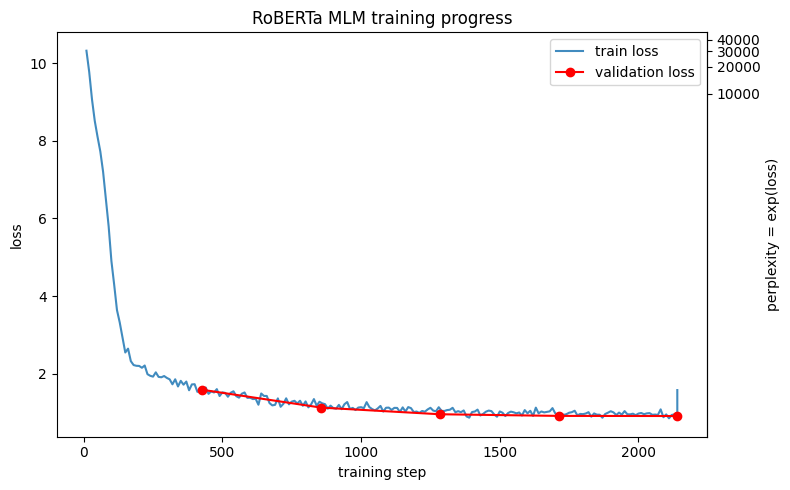

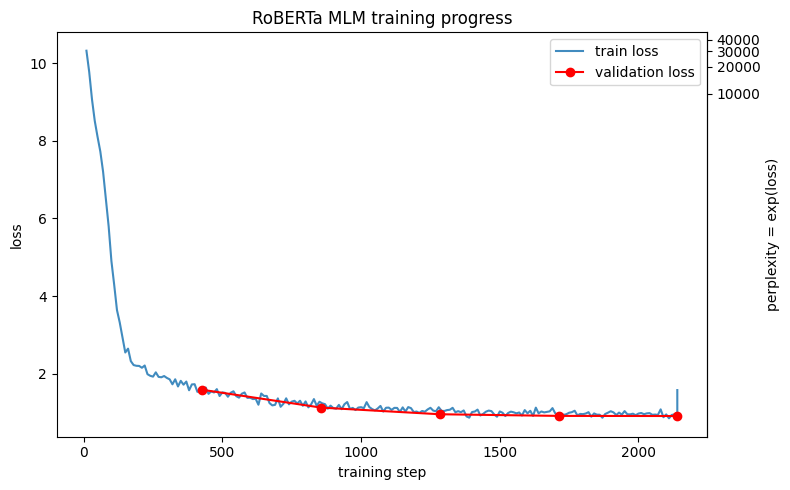

In [13]:
from http2vec.visualization.plots import plot_training_curve

fig = plot_training_curve(pipeline.training_history)
show(fig, "3_1_training_curve")

In [14]:
embeddings = pipeline.compute_embeddings(embedder, bundle)
X = embeddings.inference_x
y = embeddings.inference_y
print("inference embeddings:", X.shape, "| normal-train embeddings:", embeddings.normal_train_x.shape)

[INFO] http2vec: Embedding inference set (24426 requests).
[INFO] http2vec: Embedding normal-train set (14400 requests).


inference embeddings: (24426, 3072) | normal-train embeddings: (14400, 3072)


### 3.2 Visualising the embedding space (t-SNE)

If the representation is good, normal and anomalous requests should separate even
in 2-D. Scaling of embeddings for the classifiers is handled inside the
classifier wrappers (a `StandardScaler` for the linear models).

t-SNE on a random sample of 3000 of 24426 requests.


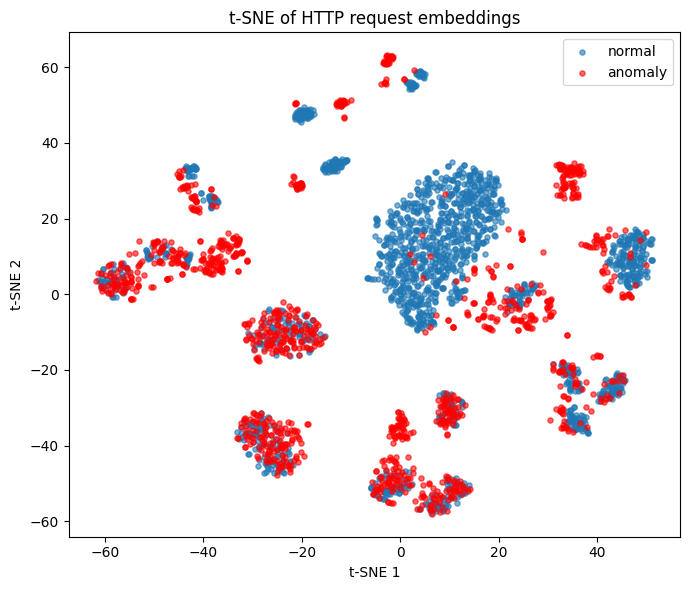

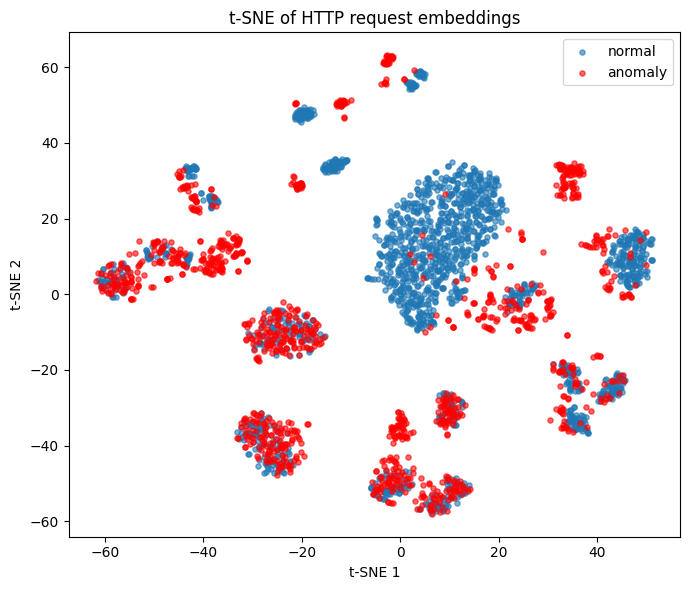

In [15]:
from http2vec.visualization.plots import plot_tsne

# t-SNE scales poorly and gets cluttered with many points; a smaller random sample
# keeps the cluster structure while giving a cleaner plot. Lower for an even
# cleaner view, raise for more detail.
rng = np.random.default_rng(config.seed)
max_points = 3000
if len(y) > max_points:
    sel = rng.choice(len(y), size=max_points, replace=False)
    tsne_x, tsne_y = X[sel], y[sel]
    print(f"t-SNE on a random sample of {max_points} of {len(y)} requests.")
else:
    tsne_x, tsne_y = X, y
fig = plot_tsne(tsne_x, tsne_y, seed=config.seed)
show(fig, "3_2_tsne_embeddings")

### 3.3 Feature engineering summary

Mapping our pipeline onto the standard feature-engineering checklist:

- **Encoding (categorical -> numeric).** Raw requests are text; the byte-level BPE
  tokenizer *is* the encoding step, turning bytes into token ids with no
  out-of-vocabulary problem. The descriptive `method` column is categorical and
  used only for EDA (the crosstab above); the model never one-hot encodes it
  because the model features are the dense embeddings.
- **Feature creation.** Two sets: human-readable descriptive features (for EDA)
  and the real model features - RoBERTa embeddings, the concatenation of the last
  4 hidden layers, mean-pooled over tokens and averaged over a request's lines
  (3072-dim for the full model).
- **Scaling.** Embeddings are standardized (`StandardScaler`) inside the linear
  classifiers, the anomaly detectors and the MLP head; tree ensembles skip it
  (scale-invariant).
- **Feature selection / dimensionality reduction.** Individual embedding
  dimensions are not human-interpretable, so we do not prune them by hand; instead
  the PCA curve below quantifies how few components already capture most variance
  (intrinsic dimensionality), and t-SNE gives a 2-D view. This is the paper's
  noted limitation (a ~3000-dim representation) made concrete.

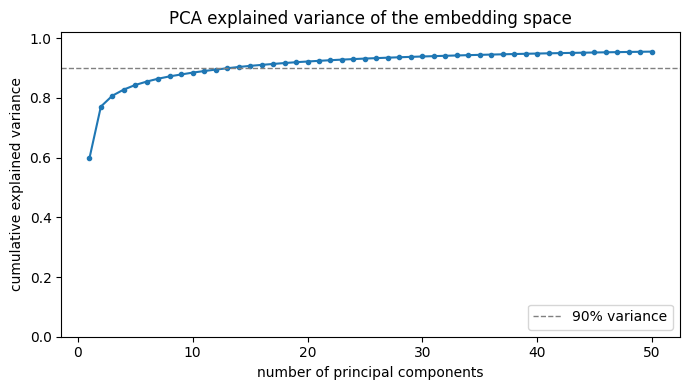

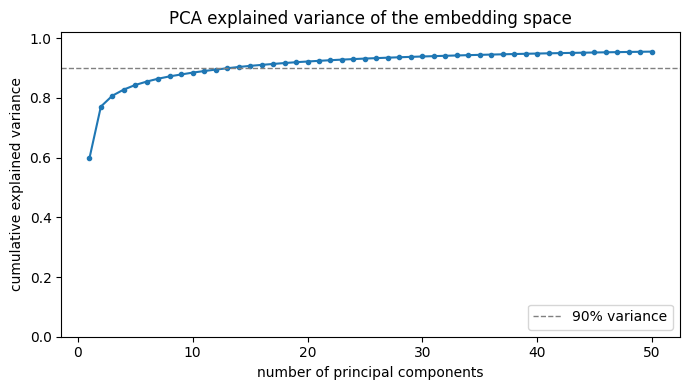

In [16]:
from http2vec.visualization.plots import plot_pca_explained_variance

fig = plot_pca_explained_variance(X, seed=config.seed)
show(fig, "3_3_pca_explained_variance")

## 4. Model training

We train the paper's supervised classifiers with **stratified k-fold
cross-validation** - Logistic Regression, Random Forest and linear SVC (the
paper's three) plus **Gradient Boosting** and **KNN** - and two unsupervised
detectors fitted on normal embeddings only: **Isolation Forest** (the paper's
spirit) and **Local Outlier Factor**. Section 4.1 adds a small trainable **MLP
head** (an extension beyond the paper). Every model exposes the same interface:
per request a continuous anomaly score and a hard class.

In [17]:
supervised_cv, supervised_holdout = pipeline.evaluate_supervised(embeddings)
anomaly = pipeline.evaluate_anomaly(embeddings)

rows = []
metric_keys = ["f1", "fbeta", "mcc", "roc_auc", "precision", "recall", "accuracy", "fpr_at_90", "fpr_at_99"]
for name, report in supervised_cv.items():
    row = {"model": name}
    row.update({k: report.cv[k]["mean"] for k in metric_keys if k in report.cv})
    rows.append(row)
cv_comparison = pd.DataFrame(rows).set_index("model")
print("Supervised classifiers - stratified 5-fold cross-validated means (paper protocol):")
cv_comparison.round(3)

Supervised classifiers - stratified 5-fold cross-validated means (paper protocol):


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.915,0.913,0.857,0.983,0.919,0.912,0.931,0.049,0.226
random_forest,0.833,0.839,0.714,0.950,0.823,0.843,0.861,0.175,0.322
linear_svc,0.908,0.907,0.845,0.979,0.910,0.907,0.925,0.058,0.300
gradient_boosting,0.860,0.862,0.762,0.964,0.857,0.863,0.885,0.133,0.284
knn,0.801,0.766,0.685,0.946,0.868,0.744,0.848,0.199,0.358


### 4.1 Trainable MLP head (extension beyond the paper)

Beyond the paper's frozen-embedding + classic-classifier recipe, we train a small
**MLP head** directly on the (still frozen) RoBERTa embeddings. Unlike the
language model - which sees only normal traffic - this head is *supervised*: it
uses labels, like the other classifiers. It is cheap, so we run it for several
epochs and capture a detailed train/validation learning curve. This is a
"fine-tune-like" addition: the RoBERTa weights themselves are not updated, only a
classifier on top of the embeddings. It is scored on the same shared holdout as
every other model, so it joins the unified comparison below on equal footing.

[INFO] http2vec: Trained MLP head: 18 epoch(s) run, best val_loss=0.1832 (restored).


MLP head (shared holdout): {'accuracy': 0.914, 'precision': 0.898, 'recall': 0.891, 'f1': 0.894, 'fbeta': 0.892, 'mcc': 0.821, 'roc_auc': 0.981, 'fpr_at_90': 0.077, 'fpr_at_99': 0.199}


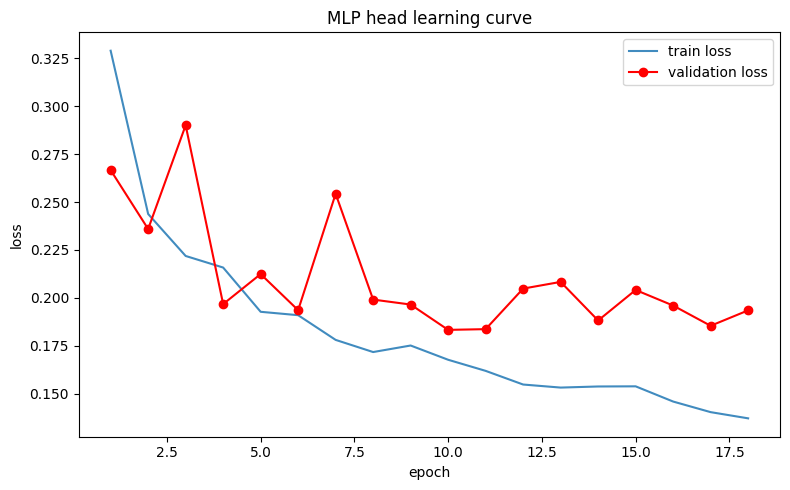

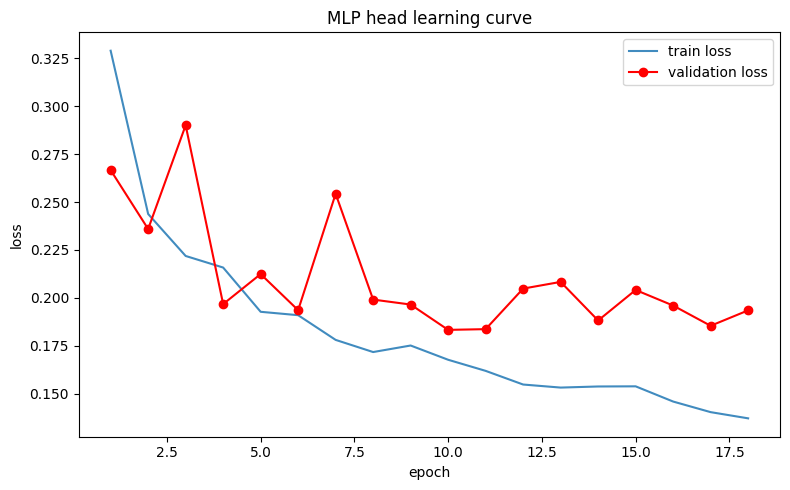

In [18]:
mlp_report, mlp_history = pipeline.evaluate_mlp_head(embeddings)
print("MLP head (shared holdout):",
      {k: round(v, 3) for k, v in mlp_report.metrics.items() if isinstance(v, float)})

fig = plot_training_curve(mlp_history, title="MLP head learning curve", show_perplexity=False)
show(fig, "4_1_mlp_learning_curve")

### 4.2 Unified model comparison (shared holdout)

The cross-validation above follows the paper for the supervised models, but to
compare *every* model - supervised, unsupervised and the MLP head - on an equal
footing we use **one shared, seeded stratified holdout split**: each supervised
model and the MLP head are trained on the same train split and scored on the same
test split, while the unsupervised detectors are fit on normal-only embeddings
and scored on that same test set. All the views below are built from a single
registry of per-model reports, so adding a model makes it appear everywhere.

In [19]:
from http2vec.pipeline import comparison_frame
from http2vec.visualization.plots import plot_model_comparison

# One registry: name -> ClassificationReport, all on the SAME holdout test set.
model_reports = {}
model_reports.update(pipeline.evaluate_supervised_holdouts(embeddings))
model_reports.update(pipeline.evaluate_anomaly_detectors(embeddings))
model_reports["mlp_head (fine-tune)"] = mlp_report  # trained in Section 4.1

comparison_all = comparison_frame(model_reports)
print("Unified comparison on the shared holdout test set:")
comparison_all.round(3)

Unified comparison on the shared holdout test set:


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.913,0.911,0.853,0.983,0.917,0.910,0.929,0.051,0.215
random_forest,0.836,0.840,0.721,0.950,0.830,0.843,0.864,0.174,0.352
linear_svc,0.910,0.909,0.847,0.980,0.912,0.908,0.926,0.056,0.281
gradient_boosting,0.857,0.854,0.759,0.963,0.862,0.852,0.883,0.128,0.296
knn,0.798,0.759,0.683,0.944,0.873,0.735,0.847,0.194,0.344
isolation_forest,0.446,0.381,0.234,0.752,0.621,0.347,0.645,0.467,0.768
local_outlier_factor,0.335,0.240,0.360,0.837,1.000,0.201,0.672,0.648,0.953
mlp_head (fine-tune),0.894,0.892,0.821,0.981,0.898,0.891,0.914,0.077,0.199


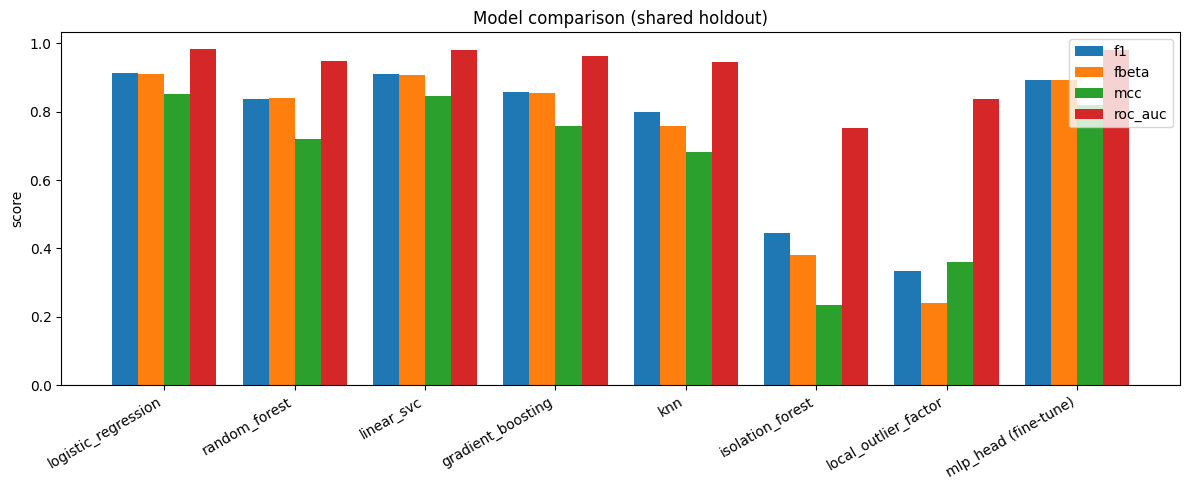

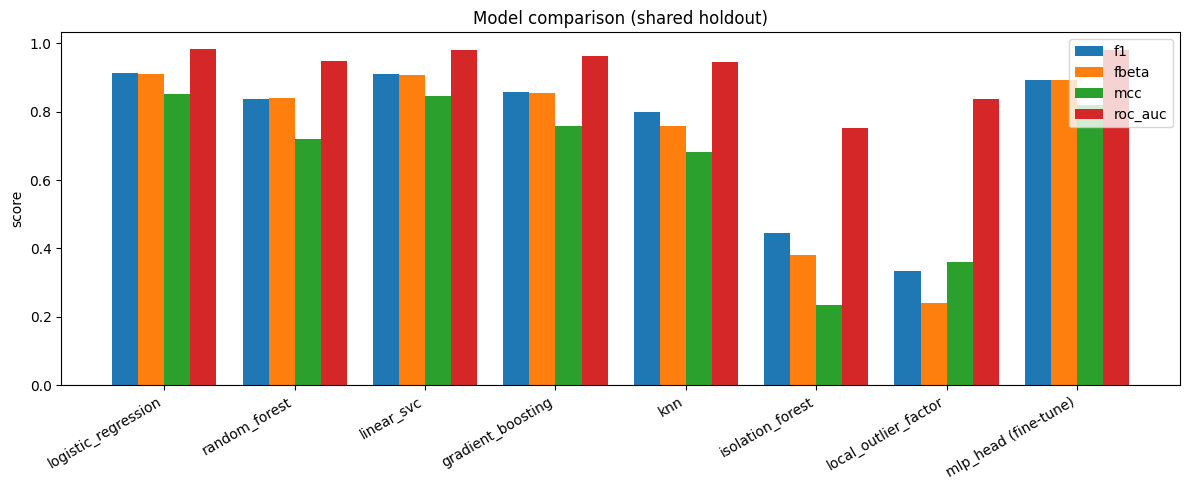

In [20]:
fig = plot_model_comparison(comparison_all, metrics=["f1", "fbeta", "mcc", "roc_auc"])
show(fig, "4_2_model_comparison_bars")

## 5. Evaluation

### Metrics and why they matter in this domain

- **Precision** - of the requests we flag as attacks, how many really are. Low
  precision means many **false positives** (benign traffic blocked - operator
  fatigue).
- **Recall (TPR)** - of the real attacks, how many we catch. Low recall means
  **false negatives** (attacks slip through - the dangerous failure).
- **F1 / Fβ** - harmonic mean of precision and recall; we use **β=2** to weight
  recall higher, because missing an attack is usually costlier than a false alarm.
- **MCC** - balanced even under class imbalance; robust single-number summary.
- **ROC-AUC** - threshold-independent ranking quality of the anomaly score.
- **FPR@TPR (FPR90/FPR99)** - the paper's headline: how many false positives we
  must accept to catch 90% / 99% of attacks.

### 5.1 ROC comparison (all models, shared holdout)

Every model from the registry overlaid on one ROC plot, so their threshold-free
ranking quality is directly comparable on the same test set.

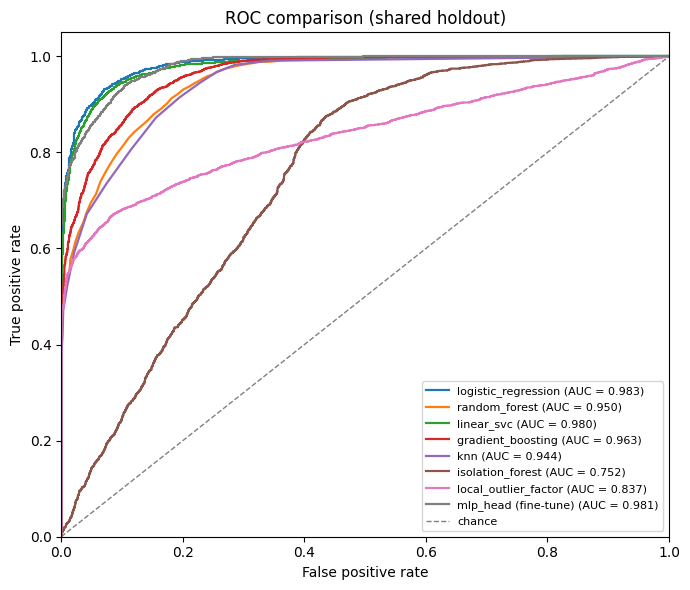

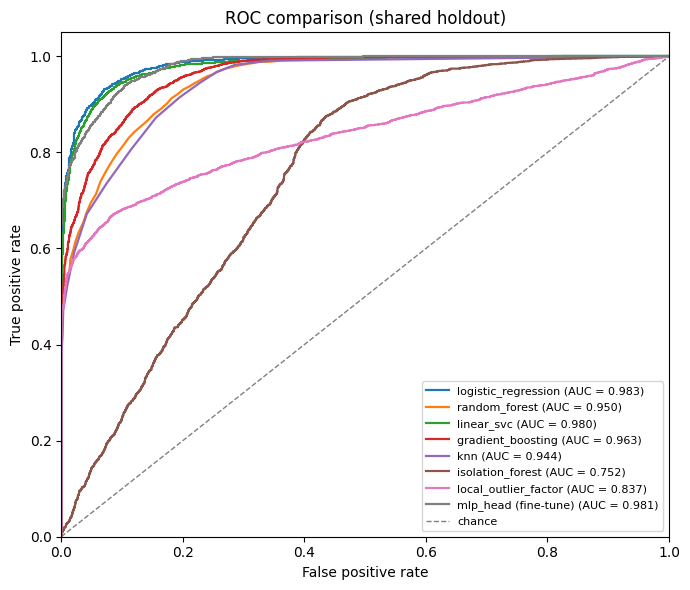

In [21]:
from http2vec.visualization.plots import plot_roc_comparison

roc_curves = {name: (report.y_true, report.y_score) for name, report in model_reports.items()}
fig = plot_roc_comparison(roc_curves)
show(fig, "5_1_roc_comparison")

### 5.2 Best supervised model (holdout)

A closer look at the single best supervised model: its confusion matrix and ROC.

Best supervised model on holdout: logistic_regression
{'accuracy': 0.929, 'precision': 0.917, 'recall': 0.91, 'f1': 0.913, 'fbeta': 0.911, 'mcc': 0.853, 'roc_auc': 0.983, 'fpr_at_90': 0.051, 'fpr_at_99': 0.215}


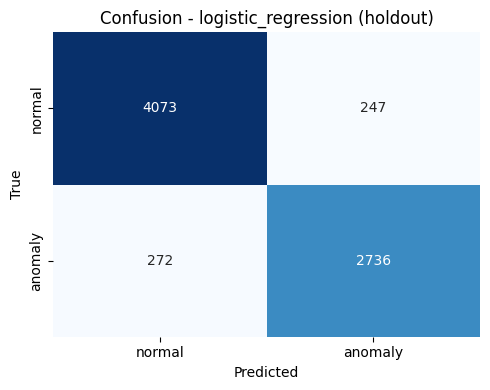

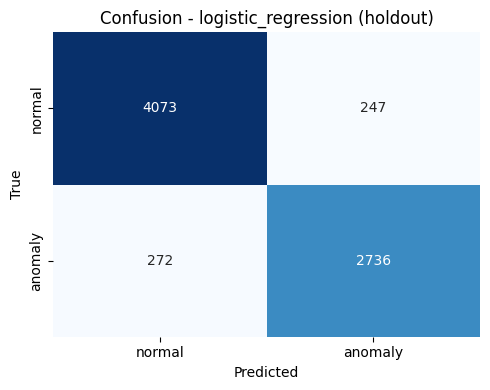

In [22]:
from http2vec.visualization.plots import plot_roc, plot_confusion_matrix, plot_score_distribution

print(f"Best supervised model on holdout: {supervised_holdout.name}")
print({k: round(v, 3) for k, v in supervised_holdout.metrics.items() if isinstance(v, float)})
fig = plot_confusion_matrix(supervised_holdout.y_true, supervised_holdout.y_pred,
                            title=f"Confusion - {supervised_holdout.name} (holdout)")
show(fig, "5_2_confusion_best_supervised")

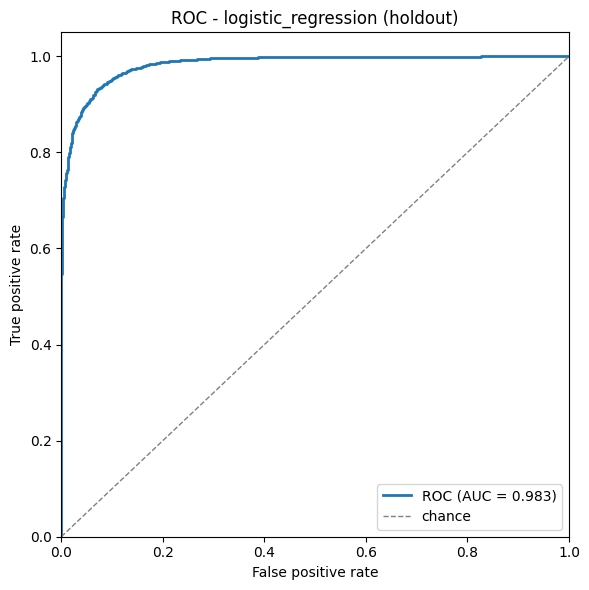

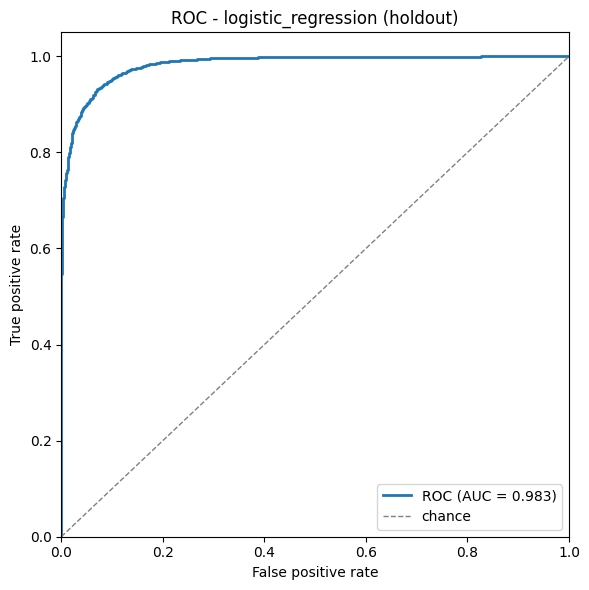

In [23]:
fig = plot_roc(supervised_holdout.y_true, supervised_holdout.y_score,
               title=f"ROC - {supervised_holdout.name} (holdout)")
show(fig, "5_2_roc_best_supervised")

### 5.3 Unsupervised detector (Isolation Forest)

Fitted on normal embeddings only, then asked to score the (mixed) inference set.
The two outputs per request are shown: the score distribution (degree of anomaly)
and the assigned class (confusion matrix).

Isolation Forest metrics (full inference set):
{'accuracy': 0.646, 'precision': 0.626, 'recall': 0.343, 'f1': 0.443, 'fbeta': 0.377, 'mcc': 0.236, 'roc_auc': 0.754, 'fpr_at_90': 0.471, 'fpr_at_99': 0.749}


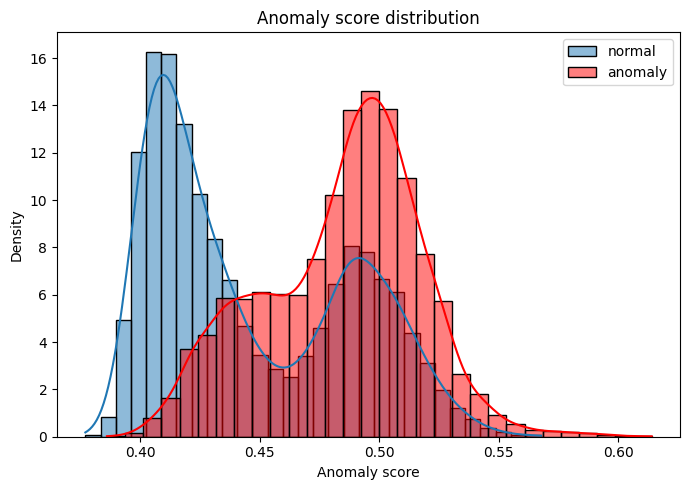

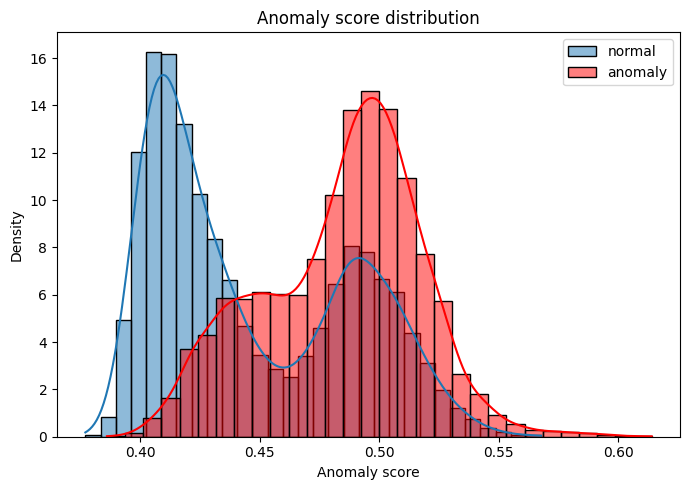

In [24]:
print("Isolation Forest metrics (full inference set):")
print({k: round(v, 3) for k, v in anomaly.metrics.items() if isinstance(v, float)})
fig = plot_score_distribution(anomaly.y_score, anomaly.y_true)
show(fig, "5_3_iforest_score_distribution")

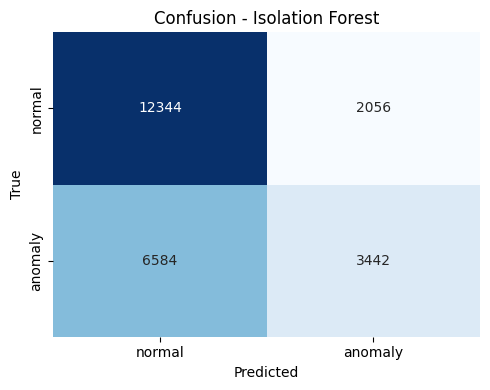

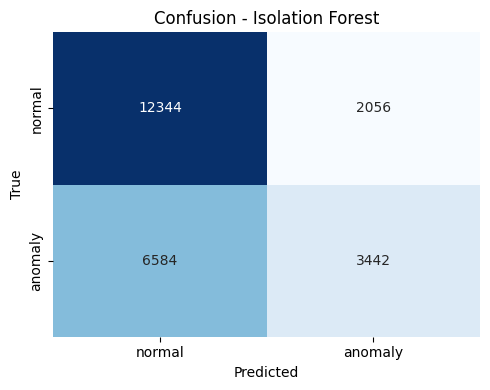

In [25]:
fig = plot_confusion_matrix(anomaly.y_true, anomaly.y_pred, title="Confusion - Isolation Forest")
show(fig, "5_3_confusion_iforest")

In [26]:
# Persist the unified comparison so the written report can cite exact numbers.
comparison_all.round(4).to_csv(REPORTS_DIR / "model_comparison.csv")
print("Saved reports/model_comparison.csv")
print("Figures saved under", FIG_DIR)

Saved reports/model_comparison.csv
Figures saved under reports/figures


## 6. Error analysis

We inspect false positives (benign flagged as attack) and false negatives
(attacks missed) from the Isolation Forest, which scores the full inference set in
order, so we can map errors straight back to the original requests.

In [27]:
inf_requests = bundle.inference.requests
y_true = anomaly.y_true
y_pred = anomaly.y_pred
fp_idx = np.where((y_pred == 1) & (y_true == 0))[0][:3]
fn_idx = np.where((y_pred == 0) & (y_true == 1))[0][:3]

print("False positives (benign flagged as attack):")
for i in fp_idx:
    print("  ", inf_requests[i].request_line[:160])
print("\nFalse negatives (attacks missed):")
for i in fn_idx:
    print("  ", inf_requests[i].request_line[:160])

print("\nFP count:", int(((y_pred == 1) & (y_true == 0)).sum()),
      "| FN count:", int(((y_pred == 0) & (y_true == 1)).sum()))

False positives (benign flagged as attack):
   GET http://localhost:8080/tienda1/publico/anadir.jsp?id=1&nombre=Jam%F3n+Ib%E9rico&precio=39&cantidad=41&B1=A%F1adir+al+carrito HTTP/1.1
   POST http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1
   POST http://localhost:8080/tienda1/publico/caracteristicas.jsp HTTP/1.1

False negatives (attacks missed):
   GET http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=bob%40%3CSCRipt%3Ealert%28Paros%29%3C%2FscrIPT%3E.parosproxy.org&pwd=84m3ri156&rememb
   GET http://localhost:8080/tienda1/publico/autenticar.jsp?modo=entrar&login=grimshaw&pwd=84m3ri156&rememberA=on&B1=Entrar HTTP/1.1
   GET http://localhost:8080/tienda1/publico/entrar.jsp?errorMsg=%2B HTTP/1.1

FP count: 2056 | FN count: 6584


**False positive vs false negative trade-off.** In intrusion detection a false
negative (a missed attack) is typically far more costly than a false positive (a
false alarm). That is why we emphasise recall (Fβ with β=2) and report FPR at high
TPR: we want to catch almost all attacks while keeping the false-alarm rate
operationally acceptable. The decision threshold on the anomaly score is the knob
that trades one for the other.

## 7. Executive summary

The cell below assembles this run's headline numbers so the written report can
quote exact figures. It prints a compact recap and writes
`reports/results_summary.json`; the full per-model table is in
`reports/model_comparison.csv` and every figure is under `reports/figures/`.

In [28]:
import json

best_overall = comparison_all["f1"].idxmax()
summary = {
    "profile": PROFILE,
    "config": {
        "epochs": config.model.num_train_epochs,
        "subset_fraction": config.data.subset_fraction,
        "embedding_dim": int(embedder.embedding_dim),
    },
    "class_balance": {"normal": int((y == 0).sum()), "anomaly": int((y == 1).sum())},
    "best_supervised_holdout": supervised_holdout.name,
    "best_model_overall_by_f1": best_overall,
    "metrics_by_model": {
        name: {k: round(float(v), 4)
               for k, v in report.metrics.items()
               if isinstance(v, float) and v == v}
        for name, report in model_reports.items()
    },
}
(REPORTS_DIR / "results_summary.json").write_text(json.dumps(summary, indent=2))
print("Best model overall (by F1):", best_overall)
print("Saved reports/results_summary.json and reports/model_comparison.csv")
comparison_all.round(3)

Best model overall (by F1): logistic_regression
Saved reports/results_summary.json and reports/model_comparison.csv


,f1,fbeta,mcc,roc_auc,precision,recall,accuracy,fpr_at_90,fpr_at_99
model,,,,,,,,,
logistic_regression,0.913,0.911,0.853,0.983,0.917,0.910,0.929,0.051,0.215
random_forest,0.836,0.840,0.721,0.950,0.830,0.843,0.864,0.174,0.352
linear_svc,0.910,0.909,0.847,0.980,0.912,0.908,0.926,0.056,0.281
gradient_boosting,0.857,0.854,0.759,0.963,0.862,0.852,0.883,0.128,0.296
knn,0.798,0.759,0.683,0.944,0.873,0.735,0.847,0.194,0.344
isolation_forest,0.446,0.381,0.234,0.752,0.621,0.347,0.645,0.467,0.768
local_outlier_factor,0.335,0.240,0.360,0.837,1.000,0.201,0.672,0.648,0.953
mlp_head (fine-tune),0.894,0.892,0.821,0.981,0.898,0.891,0.914,0.077,0.199


**Recap.**

- **Problem:** detect anomalous/attack HTTP requests on CSIC 2010.
- **Method:** RoBERTa embeddings of requests (LM trained on normal traffic only)
  plus supervised classifiers, two unsupervised detectors (Isolation Forest, LOF),
  and a trainable MLP head over the frozen embeddings.
- **Findings:** the embedding space separates classes (t-SNE), supervised models
  reach strong F1/MCC, the MLP head adds a learnable comparison point, and the
  unsupervised detectors give a per-request anomaly score without training labels.
- **Caveats:** the numbers reflect the selected profile (default `small`: the
  full-size model on a 40% subset, 5 epochs); use `paper` for the full run.